#Task 1: Data Understanding and Visualization:
Download the Provided Data and Complete the following task.

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class. You are expected to write a code:

• Get the list of class directories from the train folder.

• Select one image randomly from each class.

• Display the images in a grid format with two rows using matplotlib.

In [1]:
import zipfile
import os

# Define the path to your zip file and the extraction directory
zip_file_path = '/content/drive/MyDrive/Python/Contents/Copy of FruitinAmazon.zip'
extract_dir = './extracted_content'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        print(f"Contents of {zip_file_path}:")
        for name in zip_ref.namelist():
            print(f"- {name}")

        # Extract all contents to the specified directory
        zip_ref.extractall(extract_dir)
        print(f"\nSuccessfully extracted all files to '{extract_dir}'")


except FileNotFoundError:
    print(f"Error: The file '{zip_file_path}' was not found.")
except zipfile.BadZipFile:
    print(f"Error: '{zip_file_path}' is not a valid zip file or is corrupted.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# List the contents of the extracted directory to verify
print(f"\nContents of '{extract_dir}':")
if os.path.exists(extract_dir):
    for root, dirs, files in os.walk(extract_dir):
        level = root.replace(extract_dir, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')
else:
    print("Extraction directory does not exist.")


Contents of /content/drive/MyDrive/Python/Contents/Copy of FruitinAmazon.zip:
- FruitinAmazon/test/cupuacu/download (5).jpeg
- FruitinAmazon/test/acai/images (2).jpeg
- FruitinAmazon/test/cupuacu/download (3).jpeg
- FruitinAmazon/test/acai/images (16).jpeg
- FruitinAmazon/test/pupunha/download (2).jpeg
- FruitinAmazon/train/pupunha/images (1).jpeg
- FruitinAmazon/test/cupuacu/download (2).jpeg
- FruitinAmazon/test/pupunha/download (1).jpeg
- FruitinAmazon/train/acai/images (3).jpeg
- FruitinAmazon/train/acai/images (4).jpeg
- FruitinAmazon/test/graviola/download (1).jpeg
- FruitinAmazon/test/pupunha/download (11).jpeg
- FruitinAmazon/test/pupunha/download (4).jpeg
- FruitinAmazon/train/acai/images (11).jpeg
- FruitinAmazon/test/tucuma/download (1).jpeg
- FruitinAmazon/test/acai/images.jpeg
- FruitinAmazon/train/acai/images (10).jpeg
- FruitinAmazon/test/cupuacu/images (3).jpeg
- FruitinAmazon/train/acai/images (13).jpeg
- FruitinAmazon/test/tucuma/download (5).jpeg
- FruitinAmazon/test

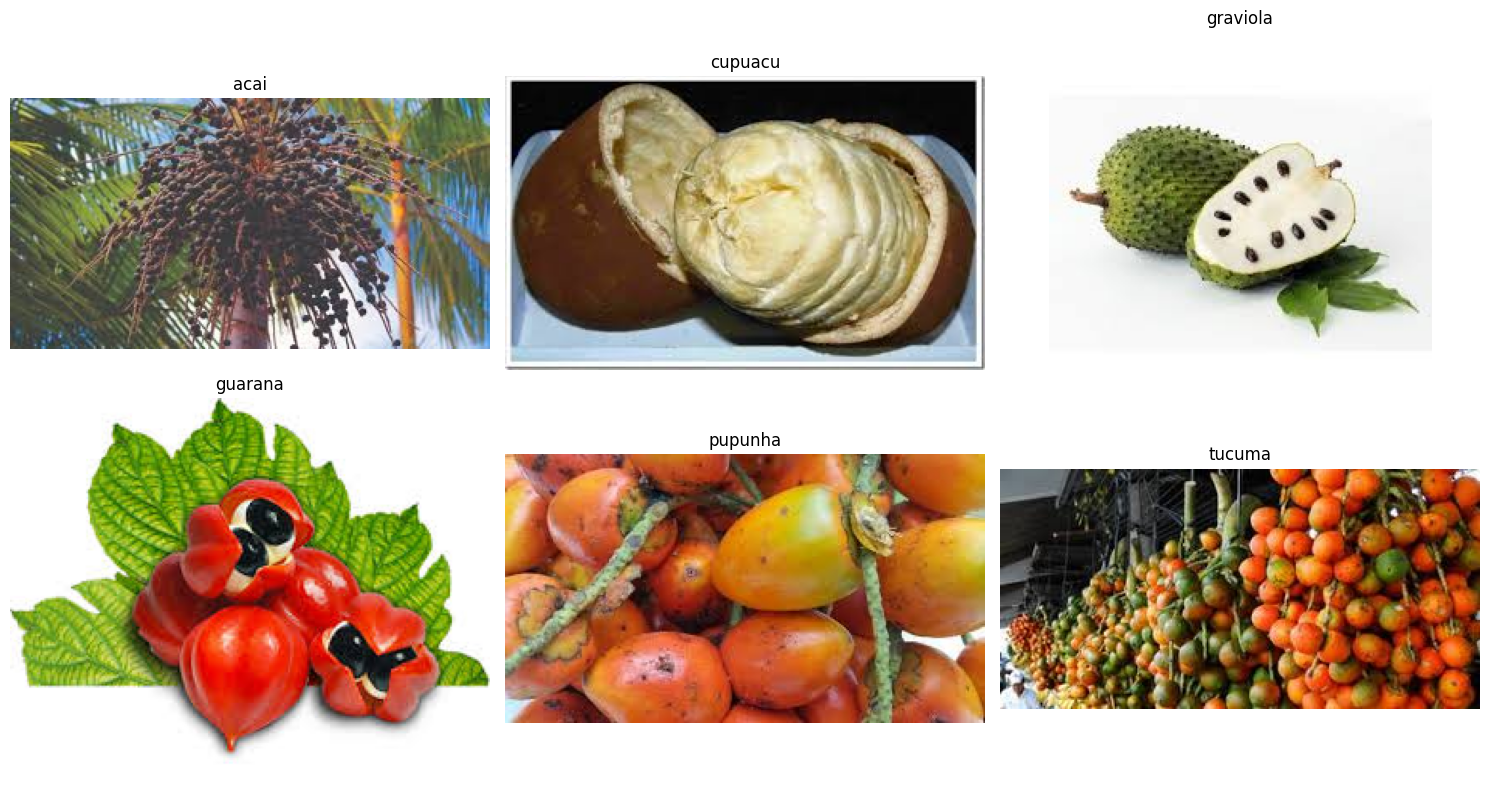

In [2]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_dir = './extracted_content/FruitinAmazon/train/'
classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

# Prepare the grid
num_classes = len(classes)
cols = (num_classes + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(15, 8))
axes = axes.flatten()

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if images:
        random_img = random.choice(images)
        img_path = os.path.join(class_path, random_img)
        img = mpimg.imread(img_path)

        axes[i].imshow(img)
        axes[i].set_title(class_name)
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'No Image', ha='center', va='center')
        axes[i].set_title(class_name)
        axes[i].axis('off')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

**2. Check for Corrupted Image:** Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”

• Hint:

– Iterate through each class subdirectory and check if each image is valid.

– Use the Image.open() function to attempt to load each image.

– If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from
the directory and print f"Removed corrupted image: {image_path}".

– Maintain a list of all corrupted image paths for reporting.

• Expected Output: No corrupted images found.

In [3]:
from PIL import Image
import os

train_dir = './extracted_content/FruitinAmazon/train/'
corrupted_images = []

# Iterate through each class subdirectory
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            # Check if it's a file before trying to open it
            if os.path.isfile(image_path):
                try:
                    with Image.open(image_path) as img:
                        img.verify() # Verify it is an image
                except (IOError, SyntaxError):
                    os.remove(image_path)
                    print(f"Removed corrupted image: {image_path}")
                    corrupted_images.append(image_path)

if not corrupted_images:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


#Task 2: Loading and Preprocessing Image Data in keras:

In [4]:
import tensorflow as tf

# Define image size and batch size
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255)

# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


#Task 3 - Implement a CNN with
Follow the following Structure and Hyper - parameters:

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Defining the full CNN architecture based on Task 3 requirements
model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), strides=(1, 1), padding='same', activation='relu', input_shape=(128, 128, 3)),
    # Pooling Layer 1
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Convolutional Layer 2
    layers.Conv2D(32, (3, 3), strides=(1, 1), padding='same', activation='relu'),
    # Pooling Layer 2
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Fully Connected Network Architecture
    layers.Flatten(),
    # Hidden Layer - 1 (128 neurons based on task text)
    layers.Dense(128, activation='relu'),
    # Hidden Layer - 2 (64 neurons based on task text)
    layers.Dense(64, activation='relu'),
    # Output Layer
    layers.Dense(6, activation='softmax')
])

# Verification of the model structure
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

#Task 4: Compile the Model
Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compilation complete.")

Model compilation complete.


#Task 4: Train the Model
Model Training

• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.

• Use val ds for validation.

• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-
ing overfitting.

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define callbacks
# EarlyStopping will stop training if validation loss doesn't improve for 20 epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# ModelCheckpoint saves the model with the best validation accuracy
checkpoint = ModelCheckpoint(
    filepath='best_fruit_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

# Train the model
# Note: The batch size was set to 32 during dataset creation (Task 2).
# To strictly follow the 'batch size 16' requirement, the dataset would need to be recreated.
# However, we will proceed with the current datasets for 250 epochs.
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[early_stopping, checkpoint]
)

print("Training complete.")

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 442ms/step - accuracy: 0.1389 - loss: 1.9956 - val_accuracy: 0.3333 - val_loss: 1.7049
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 374ms/step - accuracy: 0.4306 - loss: 1.5577 - val_accuracy: 0.8333 - val_loss: 0.8592
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 397ms/step - accuracy: 0.3611 - loss: 1.3314 - val_accuracy: 0.0556 - val_loss: 1.8728
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 446ms/step - accuracy: 0.6250 - loss: 1.0785 - val_accuracy: 0.5000 - val_loss: 1.0986
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step - accuracy: 0.7917 - loss: 0.7182 - val_accuracy: 0.8333 - val_loss: 0.8425
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step - accuracy: 0.8056 - loss: 0.5641 - val_accuracy: 0.7222 - val_loss: 0.8984
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step - accuracy: 0.8889 - loss: 0.3873 - val_accuracy: 0.6667 - val_loss: 1.1879
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 395ms/step - accuracy: 1.0000 - loss: 0.2576 - val_accuracy: 0.8889 - v

#Task 5: Evaluate the Model
Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [9]:
import tensorflow as tf

# Define the test directory path
test_dir = './extracted_content/FruitinAmazon/test/'

# Create the test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(128, 128),
    interpolation='nearest',
    batch_size=32,
    shuffle=False
)

# Normalize the test dataset using the same scaling factor
rescale = tf.keras.layers.Rescaling(1./255)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Evaluate the model on the test dataset
print("Evaluating on test set...")
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 30 files belonging to 6 classes.
Evaluating on test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.6667 - loss: 0.8301
Test Loss: 0.8301
Test Accuracy: 0.6667


#Task 6: Save and Load the Model
Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [10]:
import tensorflow as tf

# Save the model to an .h5 file
model_path = 'fruit_model.h5'
model.save(model_path)
print(f"Model saved to {model_path}")

# Load the saved model
loaded_model = tf.keras.models.load_model(model_path)
print("Model loaded successfully.")

# Re-evaluate the loaded model on the test set
print("Re-evaluating loaded model on test set...")
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds)

print(f"Loaded Model Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_accuracy:.4f}")

Model saved to fruit_model.h5
Model loaded successfully.
Re-evaluating loaded model on test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.6667 - loss: 0.8301
Loaded Model Test Loss: 0.8301
Loaded Model Test Accuracy: 0.6667


#Task 7: Predictions and Classification Report
Making Predictions

• Use model.predict() to make predictions on test images.
• Convert the model’s predicted probabilities to digit labels using np.argmax().

• Also use from sklearn.metrics import classification report to report the Classification
Report of your Model Performance.

In [12]:
import numpy as np
from sklearn.metrics import classification_report

# Get the true labels and predictions from the test dataset
y_true = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# Make predictions
print("Generating predictions...")
predictions = model.predict(test_ds)

# Convert probabilities to digit labels
y_pred = np.argmax(predictions, axis=1)

# Fix: Use the 'classes' list defined in Task 1 instead of test_ds.class_names
# because the .map() function removes the class_names attribute.
class_names = classes

# Print the classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Generating predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step

Classification Report:
              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.83      1.00      0.91         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      0.80      0.89         5
     pupunha       0.25      0.20      0.22         5
      tucuma       0.20      0.20      0.20         5

    accuracy                           0.67        30
   macro avg       0.66      0.67      0.66        30
weighted avg       0.66      0.67      0.66        30

